In [1]:
import pandas as pd
import numpy as np
from src_RF_DT import *
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# 1.0 - Classificação do Desempenho Baseado em Fatores Socioeconômicos Usando Decision Tree

In [2]:
colunas = ['Q001','Q002','Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 
           'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'TP_PRESENCA_LC', 'TP_PRESENCA_CH', 'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 
           'TP_FAIXA_ETARIA', 'TP_ESTADO_CIVIL', 'TP_ESCOLA', 'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 
           'NU_ANO', 'TP_LOCALIZACAO_ESC','TP_SIT_FUNC_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC']

df = pd.read_parquet("../data/enem_parquet", columns = colunas)

## 1.1 - Pré-Processamento dos Dados

In [3]:
df = pre_processor_rf_dt(df, objetivo = 'Desempenho', n_samples = 50_000)

## 1.2 - Construção da Matriz X e Vetor y

In [4]:
X = df.drop(columns=['MEDIA', 'FALTOU'])

y_media = df['MEDIA']

## 1.3 - Separação em Dados de Treino, Validação e Teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y_media, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [6]:
quantil = y_train.quantile(0.5)
y_train = (y_train >= quantil).astype(int)
y_val   = (y_val   >= quantil).astype(int)
y_test  = (y_test  >= quantil).astype(int)

## 1.4 - Treinando o Modelo

In [7]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

print("Ein: %0.4f" % (1 - accuracy_score(y_train, clf.predict(X_train)) ))
print("Eout: %0.4f" % (1 - accuracy_score(y_val, clf.predict(X_val)) ))

print(classification_report(y_val, clf.predict(X_val)))

Ein: 0.0039
Eout: 0.4024
              precision    recall  f1-score   support

           0       0.58      0.61      0.60       848
           1       0.62      0.58      0.60       904

    accuracy                           0.60      1752
   macro avg       0.60      0.60      0.60      1752
weighted avg       0.60      0.60      0.60      1752



## 1.5 - Plotando a Árvore

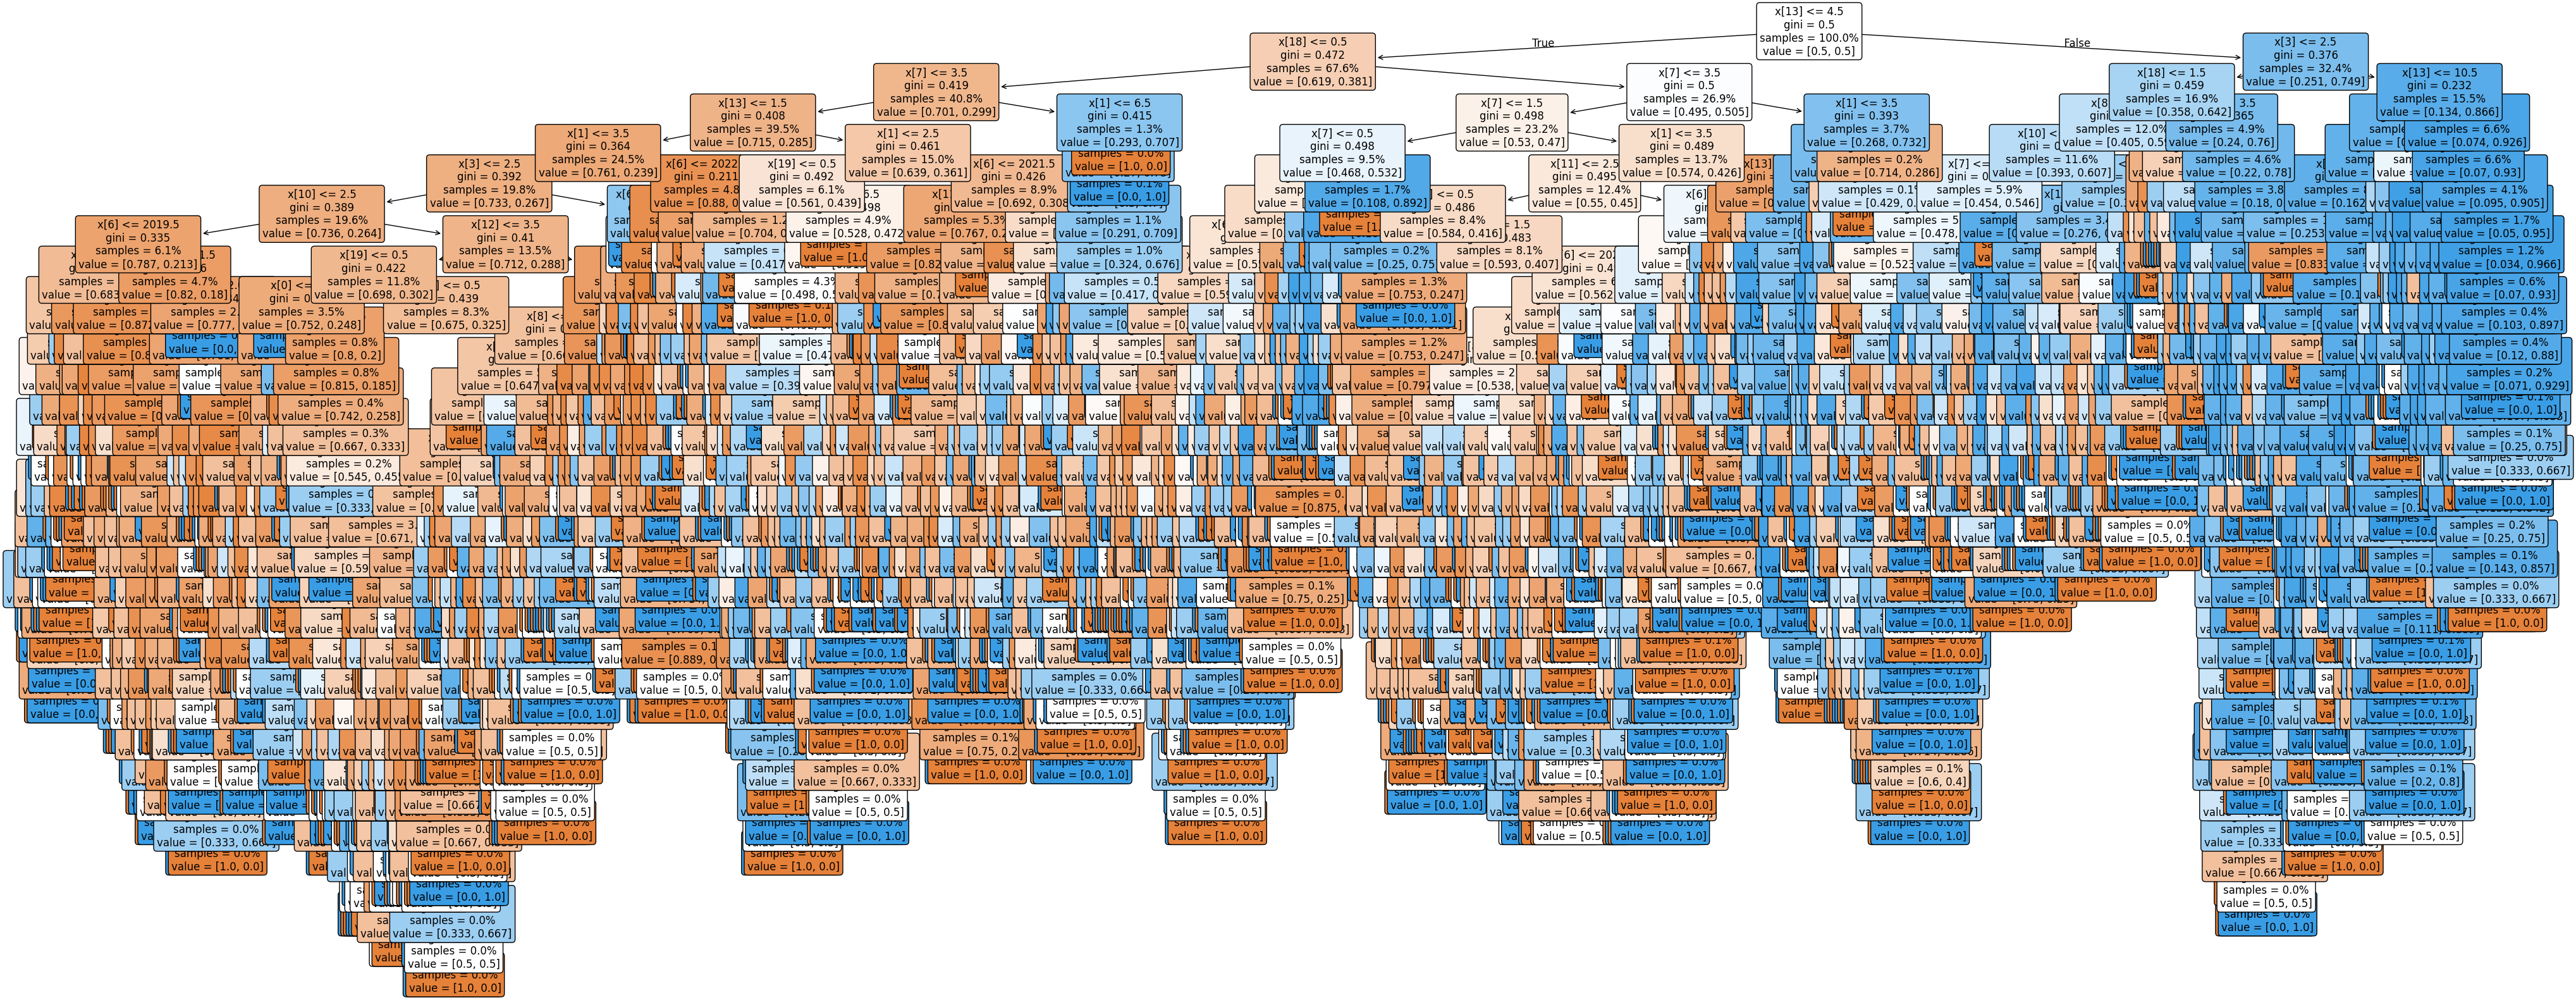

In [8]:
plt.figure(figsize=(50,20))

plot_tree(
    clf,
    filled=True, 
    proportion = True,
    fontsize=12, 
    rounded = True)

plt.show()

## 1.6 - Utilizando o algoritmo de Minimal Cost-Complexity

C:\Users\sergi\AppData\Local\Temp\ipykernel_7940\306740880.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


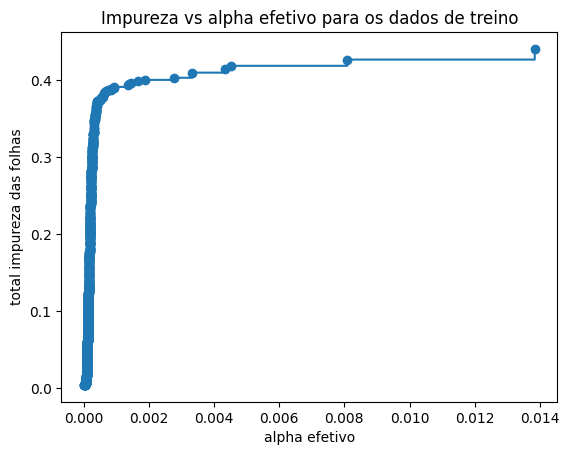

In [9]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("alpha efetivo")
ax.set_ylabel("total impureza das folhas")
ax.set_title("Impureza vs alpha efetivo para os dados de treino")
fig.show()

## 1.7 - Regularizar o alpha com Minimal Cost-Complexity via cross-validation

In [10]:
alphas_reduzidos = np.unique(np.quantile(path.ccp_alphas, np.linspace(0, 1, 200)))

param_grid = {
    'ccp_alpha': alphas_reduzidos,
    'class_weight':[None,'balanced'],
    'max_depth': [3, 5, 10, 15],
}

CV_clf = GridSearchCV(estimator=clf, param_grid=param_grid, cv = 5, verbose=2, n_jobs=-1)

CV_clf.fit(X_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, CV_clf.predict(X_train))))
print('Eval: %0.4f' % (1 - accuracy_score(y_val, CV_clf.predict(X_val))))

print(classification_report(y_val, CV_clf.predict(X_val)))

Fitting 5 folds for each of 1312 candidates, totalling 6560 fits
Ein: 0.2960
Eval: 0.3019
              precision    recall  f1-score   support

           0       0.65      0.81      0.72       848
           1       0.77      0.60      0.67       904

    accuracy                           0.70      1752
   macro avg       0.71      0.70      0.70      1752
weighted avg       0.71      0.70      0.70      1752



In [11]:
CV_clf.best_params_

{'ccp_alpha': 0.000762393368470725, 'class_weight': None, 'max_depth': 10}

## Treinando o modelo com todos os dados

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y_media, test_size=0.2, random_state=42)

quantil = y_train.quantile(0.5)
y_train = (y_train >= quantil).astype(int)
y_test  = (y_test  >= quantil).astype(int)

clf = DecisionTreeClassifier(**CV_clf.best_params_)
clf.fit(X_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, CV_clf.predict(X_train))))
print('Eval: %0.4f' % (1 - accuracy_score(y_test, CV_clf.predict(X_test))))

print(classification_report(y_test, clf.predict(X_test)))

Ein: 0.2965
Eval: 0.3128
              precision    recall  f1-score   support

           0       0.69      0.77      0.73      1136
           1       0.72      0.63      0.67      1054

    accuracy                           0.70      2190
   macro avg       0.71      0.70      0.70      2190
weighted avg       0.70      0.70      0.70      2190



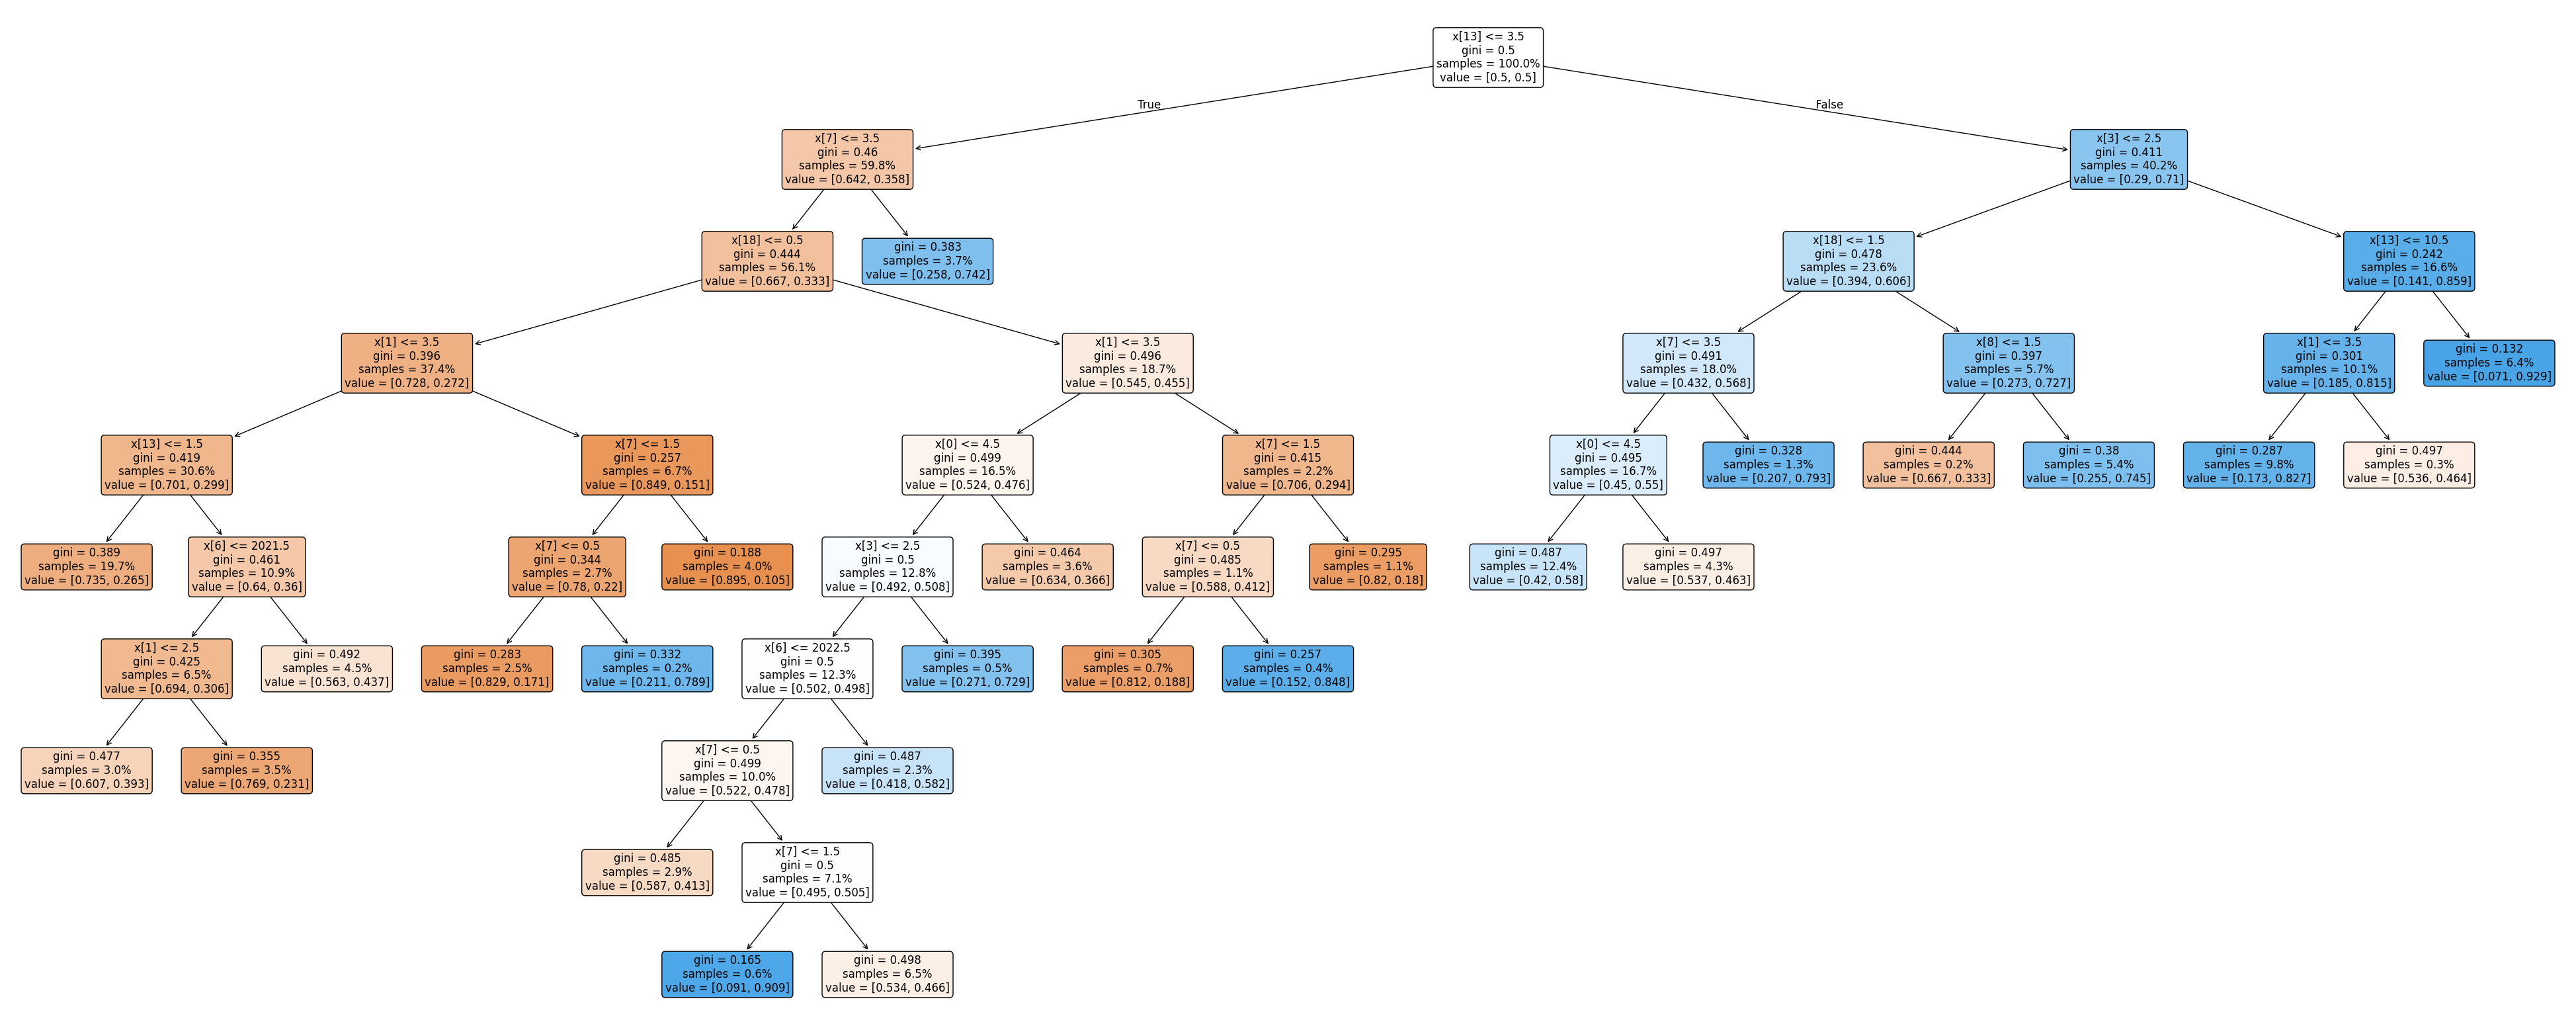

In [13]:
plt.figure(figsize=(50,20))

plot_tree(
    clf,
    filled=True,
    proportion=True,
    fontsize=12,
    rounded=True
)

plt.show()